In [40]:
using CSV
using Revise
using DataFrames
using StatsBase
using LinearAlgebra
using Distributions

using Stheno
using Measurements
using LogExpFunctions
import ComponentArrays: ComponentArray
using CairoMakie
using ColorSchemes
includet("src/rgp.jl")

In [42]:
## Dummy test
step_test = 0.01
step_basis = 1
std = 0.01
l = 0.8
batch_size = 1
mu_prior = 0
limit_test = [-10, 10]
limit_basis = [-8, 8]

## Test
X_test = collect(limit_test[1]:step_test:limit_test[2])
Y_test = sin.(X_test) + rand(Normal(0, std), size(X_test)[1])

## Basis
X_basis = collect(limit_basis[1]:step_basis:limit_basis[2])

θ = ComponentArray(;
    l = l,
    mu = mu_prior,
    std = std,
)

p, posterior = rgp(X_basis, X_test, Y_test, θ, batch_size)

((k = Squared Exponential Kernel (metric = Distances.Euclidean(0.0))
	- Scale Transform (s = 1.25), inv_cov_basis = Any[1.3389137544718532 -0.775567075940118 … -1.3788704626187965e-5 4.989667190242294e-6; -0.7755670759401179 1.788161726754188 … 3.8104420197042336e-5 -1.3788704626187975e-5; … ; -1.3788704626187965e-5 3.8104420197042315e-5 … 1.7881617267541883 -0.7755670759401182; 4.98966719024229e-6 -1.3788704626187956e-5 … -0.7755670759401182 1.3389137544718535], H = Any[-2.541098841762901e-21 8.470329472543003e-21 … -1.1102230246251565e-16 1.0], Q = Any[0.0001;;]), (basis = (mu = [-0.9934193892730391, -0.6552284327849842, 0.27952566700649006, 0.9584384446383885, 0.7584884090696022, -0.14495312239200422, -0.9090536525986475, -0.8370490769863058, -0.0028775741790572945, 0.8435797782791699, 0.909031392876599, 0.13921670747671125, -0.7580236086668375, -0.9529516310944136, -0.27947396286063714, 0.6552139573605735, 0.9852679379035844], cov = [2.873667611347467e-5 -1.8110116245335936e-7 … -5

## Plots

In [43]:
mu, C = predict(p, posterior, X_test)
σ = sqrt.(diag(C))
Y_real = sin.(X_test)

2001-element Vector{Float64}:
  0.5440211108893698
  0.5356033346142913
  0.527131998452086
  0.5186079495293108
  0.5100320402437544
  0.5014051281791974
  0.49272807601966023
  0.48400175146312646
  0.4752270271347798
  0.4664047804997409
  ⋮
 -0.4752270271347798
 -0.48400175146312646
 -0.49272807601966023
 -0.5014051281791974
 -0.5100320402437544
 -0.5186079495293108
 -0.527131998452086
 -0.5356033346142913
 -0.5440211108893698

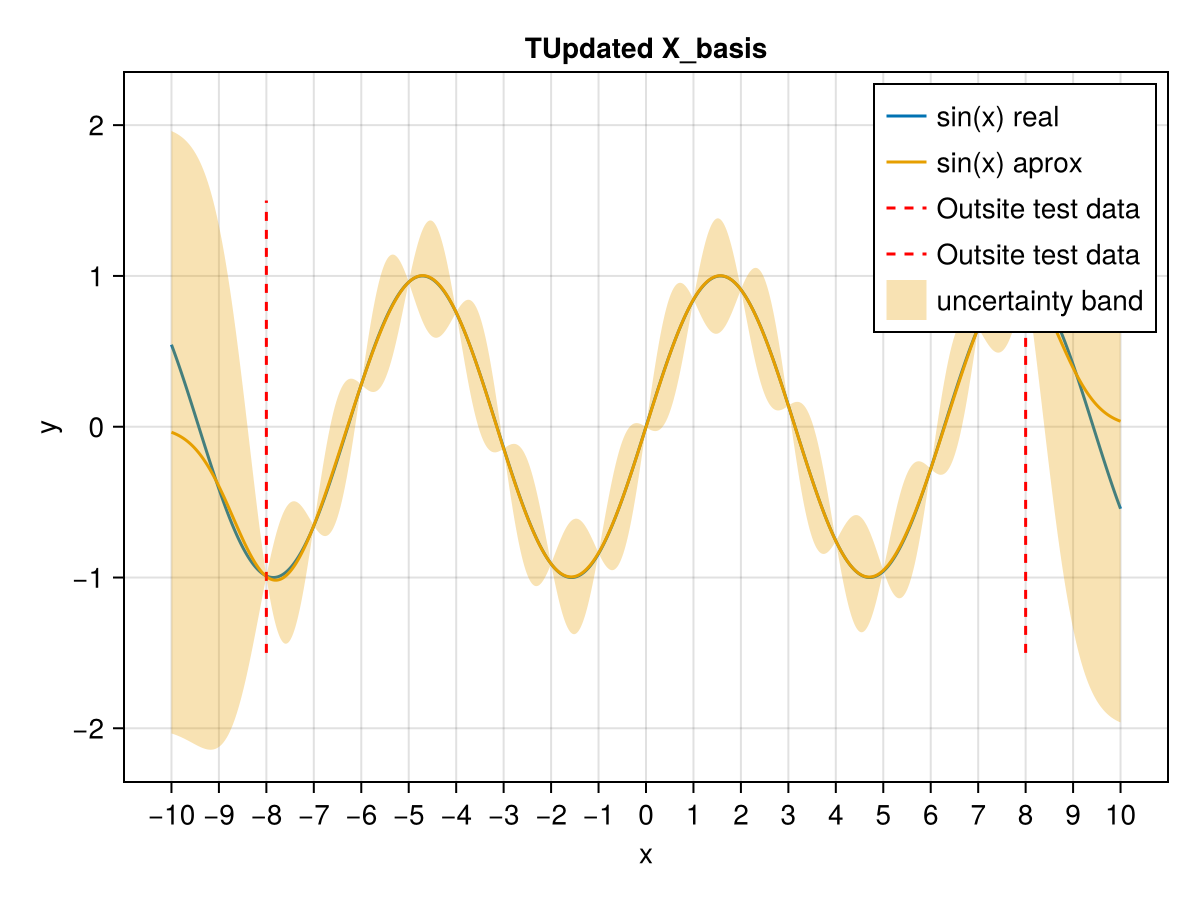

CairoMakie.Screen{IMAGE}


In [44]:
fig = Figure()
ax = Axis(fig[1, 1], title = "TUpdated X_basis", xlabel = "x", ylabel = "y", xticks = -10:1:10)
lines!(ax, X_test, Y_real, label = "sin(x) real")
lines!(ax, X_test, mu, label = "sin(x) aprox")
lines!(ax, [limit_basis[1], limit_basis[1]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")
lines!(ax, [limit_basis[2], limit_basis[2]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")

band!(ax, X_test, mu - 2σ, mu + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
axislegend(ax)
display(fig)